# Imports

In [5]:
import os
import pickle
import re
import shutil
import sys
sys.path.append(os.path.dirname(os.path.dirname(os.getcwd())))
from itertools import product
from scipy.stats import norm
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import yaml
import time
from matplotlib.backends.backend_pdf import PdfPages
from analyze.tools import load_npy, load_yaml_as_df, load_pkl, exist_metric, exist_stf_metric, inverse_stf_metrics, keep_split, is_full_group, set_seed, timing_decorator
from data_provider.data_loader import Dataset_Custom, Dataset_ETT_hour, Dataset_PEMS_PCA, Dataset_ETT_minute
from utils.polynomial import get_pca_base, Basis_Cache, pca_torch
import json

plt.style.use('default')
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
plt.rc('font', family='Arial')
matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.size'] = 10

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)


def collect_label_seq(train_data, pl):
    label_seq = []
    for i in range(len(train_data)):
        _, label, _, _ = train_data[i]
        label = label[-pl:]
        label_seq.append(label)
    label_seq = np.array(label_seq)
    return label_seq


@timing_decorator
def timing_pca(label_seq, rank_ratio, pca_dim, reinit, speedup_sklearn):
    get_pca_base(label_seq, rank_ratio, pca_dim, reinit, speedup_sklearn)
    return None

# PCA complexity

In [ ]:
dst = 'Weather'
root_path = '/data/home/Licheng/workspace/TSF-PCA/dataset/weather'
data_path = 'weather.csv'
flag = 'train'
size = [96, 48]
trys = 5

times = []

pl = 96
for dp in [0.2, 0.4, 0.6, 0.8]:
    for t in range(trys):
        set_seed(2023)
        train_data = Dataset_Custom(
            root_path=root_path,
            data_path=data_path,
            flag=flag,
            size=[96, 48, pl],
            features="M", target='OT', timeenc=1, freq='h',
            data_percentage=dp,
        )
        label_seq = collect_label_seq(train_data, pl)
        results = timing_pca(label_seq, rank_ratio=1.0, pca_dim='T', reinit=1, speedup_sklearn=2)
        times.append([pl, dp, t, results['time']])

for pl in [96, 192, 336, 720]:
    for t in range(trys):
        set_seed(2023)
        train_data = Dataset_Custom(
            root_path=root_path,
            data_path=data_path,
            flag=flag,
            size=[96, 48, pl],
            features="M", target='OT', timeenc=1, freq='h',
            data_percentage=1.0,
        )
        label_seq = collect_label_seq(train_data, pl)
        results = timing_pca(label_seq, rank_ratio=1.0, pca_dim='T', reinit=1, speedup_sklearn=2)
        times.append([pl, 1.0, t, results['time']])

times = pd.DataFrame(times, columns=['pred_len', 'data_percentage', 'try', 'time'])
save_root = '/data/home/Licheng/workspace/TSF-PCA/stats_PCA'
times.to_csv(os.path.join(save_root, f'weather_pca_time.csv'), index=False)

Head lines of raw dataframe:
                  date  p (mbar)  T (degC)  Tpot (K)  Tdew (degC)  rh (%)  \
0  2020-01-01 00:10:00   1008.89      0.71    273.18        -1.33    86.1   
1  2020-01-01 00:20:00   1008.76      0.75    273.22        -1.44    85.2   
2  2020-01-01 00:30:00   1008.66      0.73    273.21        -1.48    85.1   
3  2020-01-01 00:40:00   1008.64      0.37    272.86        -1.64    86.3   
4  2020-01-01 00:50:00   1008.61      0.33    272.82        -1.50    87.4   

   VPmax (mbar)  VPact (mbar)  VPdef (mbar)  sh (g/kg)  H2OC (mmol/mol)  \
0          6.43          5.54          0.89       3.42             5.49   
1          6.45          5.49          0.95       3.39             5.45   
2          6.44          5.48          0.96       3.39             5.43   
3          6.27          5.41          0.86       3.35             5.37   
4          6.26          5.47          0.79       3.38             5.42   

   rho (g/m**3)  wv (m/s)  max. wv (m/s)  wd (deg)  rain 

# load PCA data and plot

In [ ]:
# plot palette
palette = sns.color_palette("Purples_d", 8)
sns.palplot(palette)

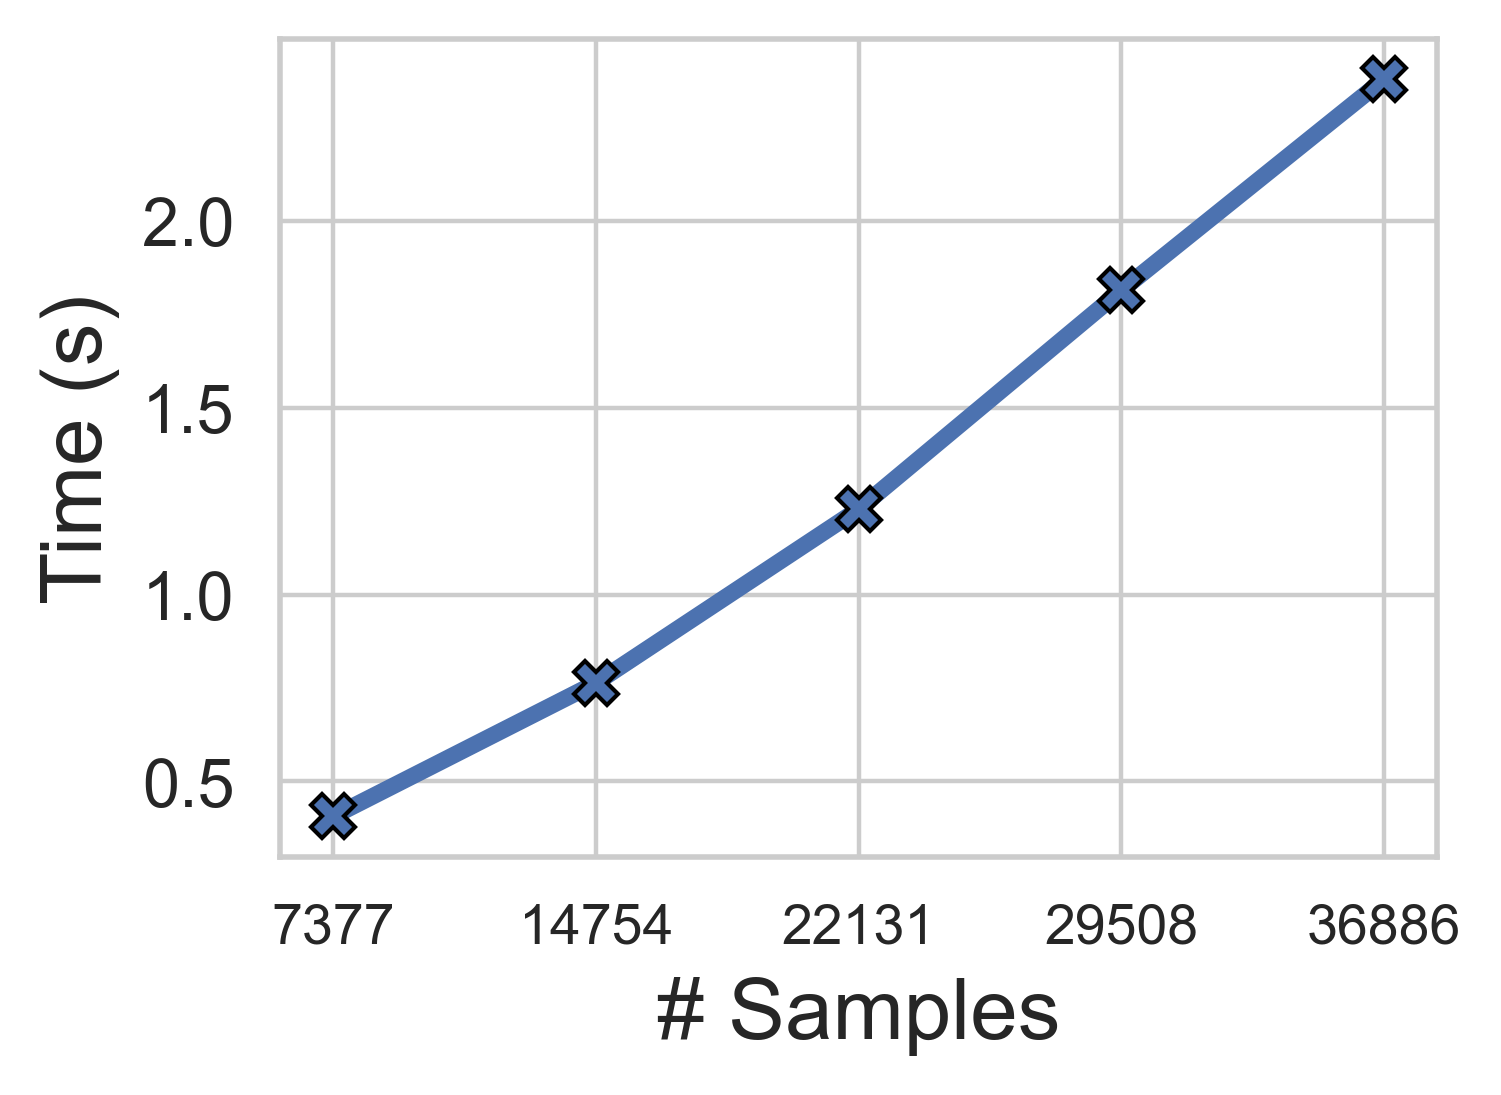

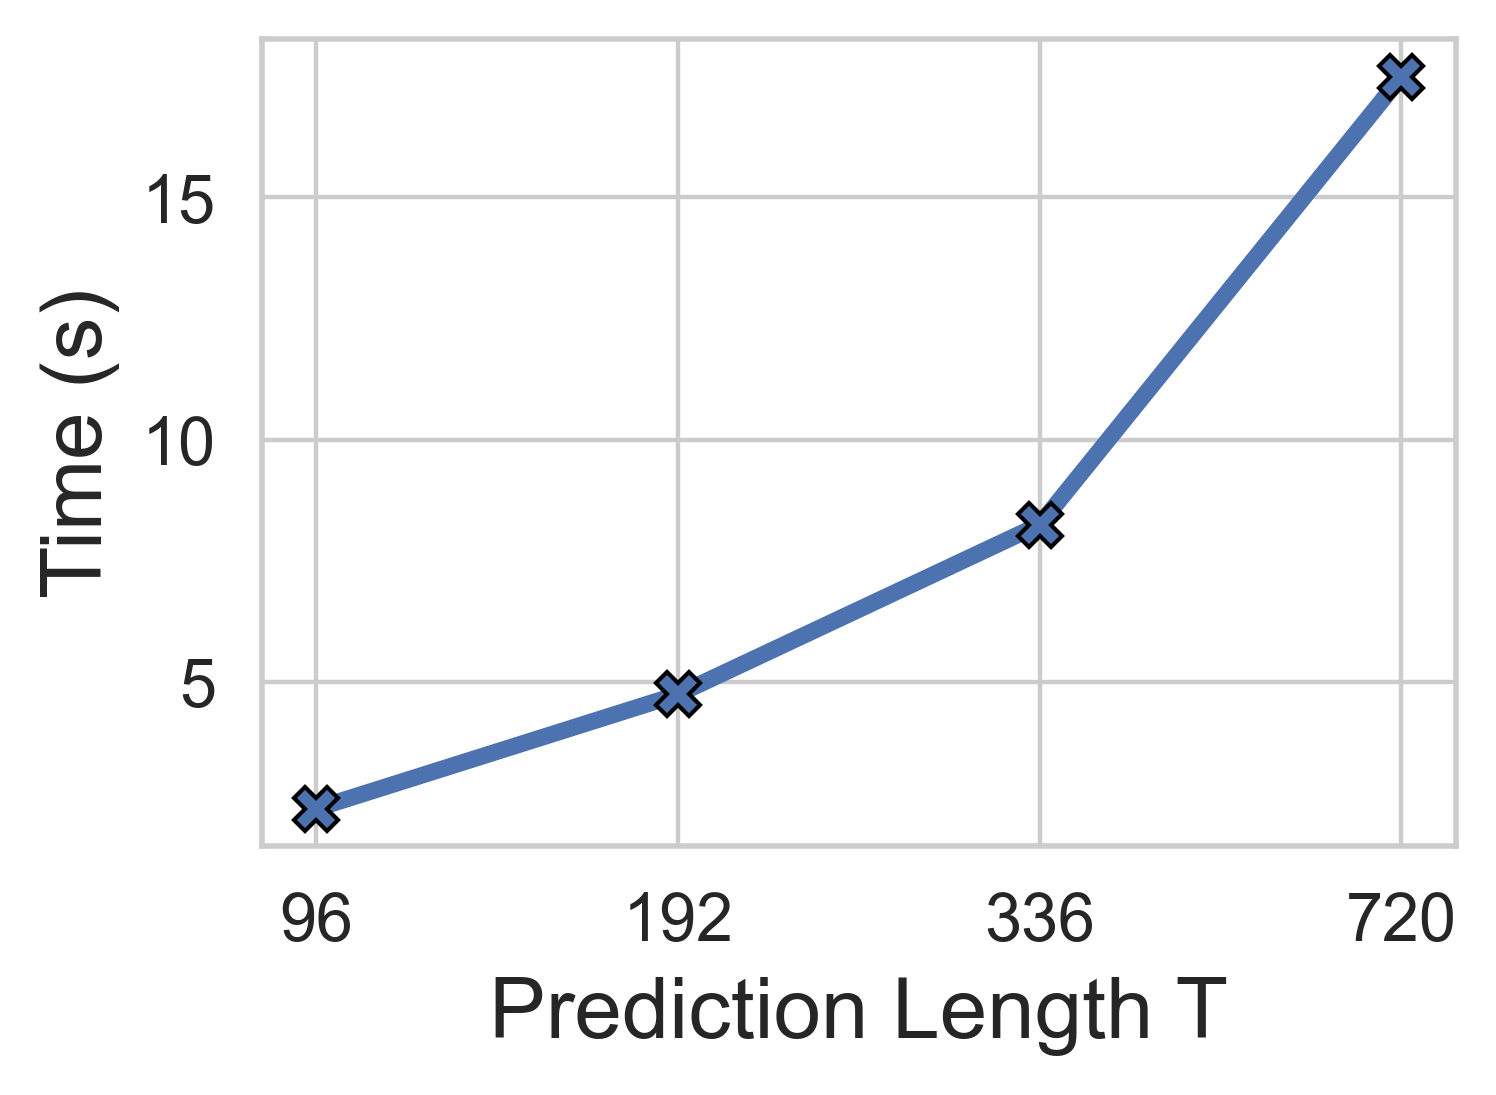

In [137]:
def plot(df, save_dir, figure_name='hparam-study', x='lambda', x_name=r'$\alpha$', ytick1=None, ytick2=None, ypad1=0.005, ypad2=0.005, ylim1=None, ylim2=None, xpad=None, xticks=None, base=10, labelsize=None):
    legend_location = 'center right'  # 这里可以根据图的实际情况调节。
    labelsize = 12 if labelsize is None else labelsize

    style = ['darkgrid', 'dark', 'white', 'whitegrid', 'ticks']
    context = ['paper', 'notebook', 'talk', 'poster']
    palette = sns.color_palette('deep')
    palette = [palette[0], palette[3], palette[2]] + palette[4:]
    # palette = sns.color_palette('Purples_d', 8)
    # palette = palette[::-1]
    sns.set_theme(style=style[3], context=context[0], font='Arial', font_scale=1.6, palette=palette)

    f = plt.figure(dpi=400, figsize=(4, 3))  # 如果只画一条线，就用红色，高改为3->2.5
    f.subplots_adjust(top=0.9, left=0.1, right=0.9, bottom=0.2)
    f.add_subplot(1, 1, 1)
    sns.lineplot(x=x, y='time', data=df, errorbar=('ci', 99.99), linewidth=3, markersize=8, markeredgecolor='k', marker='X')
    ax = plt.gca()
    if ypad1:
        ax.yaxis.set_major_locator(plt.MultipleLocator(ypad1))  # 小数点后3位数间隔。
    if xpad:
        ax.xaxis.set_major_locator(plt.MultipleLocator(xpad))
    # plt.legend(ncol=2, loc=legend_location, fontsize=labelsize)
    plt.xlabel(x_name)
    # plt.xticks(rotation=90)
    plt.ylabel('Time (s)')
    if base != 10:
        plt.yscale('log', base=base)
    # plt.tick_params(labelsize=labelsize)
    plt.tick_params(labelsize=12, axis='y')
    plt.tick_params(labelsize=labelsize, axis='x')
    if ytick1:
        plt.yticks(ytick1)
    if xticks is not None:
        plt.xticks(xticks)
    if ylim1:
        plt.ylim(ylim1)
    plt.tight_layout()

    with PdfPages(os.path.join(save_dir, f"{figure_name}.pdf")) as pdf:
        pdf.savefig(f, bbox_inches='tight', pad_inches=0.01)

save_root = '/data/home/Licheng/workspace/TSF-PCA/stats_PCA'
times = pd.read_csv(os.path.join(save_root, f'weather_pca_time.csv'))
times['data_size'] = times['data_percentage'] * 36886
times['data_size'] = times['data_size'].astype(int)

dp = times[times.pred_len == 96].copy()
dp.sort_values(by='data_percentage', inplace=True)
xticks = dp['data_size'].unique()

save_dir = '/data/home/Licheng/workspace/TSF-PCA/figure_PCA/timing'
os.makedirs(save_dir, exist_ok=True)

plot(dp, save_dir=save_dir, figure_name='weather_pca_time_dp', x='data_size', x_name=r'# Samples', ypad1=None, xticks=xticks, labelsize=10)

pld = times[times.data_percentage == 1.0].copy()
pld.sort_values(by='pred_len', inplace=True)
pld['pred_len'] = pld['pred_len'].astype(str)
xticks = pld['pred_len'].unique()
# xticks = [str(x) for x in xticks]

plot(pld, save_dir=save_dir, figure_name='weather_pca_time_pl', x='pred_len', x_name=r'Prediction Length T', ypad1=None, xticks=xticks)


# load Fredformer data and plot

In [ ]:

def load_json_profile_as_df(file):
    """
    Load a JSON file and convert it to a DataFrame.
    """
    with open(file, 'r') as f:
        data = json.load(f)
    data = data['traceEvents']
    data = [event for event in data if event['name'] in ['forward_pass', 'backward_pass', 'test_forward_pass', 'rec_loss_forward_pass', 'auxi_loss_forward_pass']]
    data = [event for event in data if event['cat'] == 'gpu_user_annotation']
    # data = [event for event in data if event['cat'] == 'user_annotation']
    data = pd.json_normalize(data)
    return data


def process_profile(profile):
    """
    Process the profile DataFrame to extract relevant information.
    For each profile type, sort by 'dur', remove the first 20 and last 20 rows.
    """
    profile = profile[['name', 'dur', 'ts']].copy()
    profile['dur'] = profile['dur'].astype(float) / 1e3  # convert to ms

    def trim_edges_by_dur(df, n=20):
        """Sort by dur, remove first n and last n rows."""
        df = df.sort_values(by='dur').reset_index(drop=True)
        if len(df) > 2 * n:
            return df.iloc[n:-n].reset_index(drop=True)
        else:
            return df.iloc[0:0]

    forward = trim_edges_by_dur(profile[profile["name"] == "forward_pass"])
    loss_forward = trim_edges_by_dur(profile[profile["name"].isin(["rec_loss_forward_pass", "auxi_loss_forward_pass"])])
    backward = trim_edges_by_dur(profile[profile["name"] == "backward_pass"])
    test_forward = trim_edges_by_dur(profile[profile["name"] == "test_forward_pass"])

    min_len = min(len(forward), len(loss_forward), len(backward), len(test_forward))
    forward = forward.head(min_len)
    loss_forward = loss_forward.head(min_len)
    backward = backward.head(min_len)
    test_forward = test_forward.head(min_len)

    profile_df = pd.DataFrame({
        "forward_pass": forward["dur"],
        "loss_forward_pass": loss_forward["dur"],
        "backward_pass": backward["dur"],
        "test_forward_pass": test_forward["dur"],
        "try": list(range(min_len)),
    })
    profile_df = profile_df.reset_index(drop=True)
    return profile_df


root = '/data/home/Licheng/workspace/TSF-PCA/results_PCA/timing2'
exp_dirs = os.listdir(root)
exp_dirs = [os.path.join(root, exp_dir) for exp_dir in exp_dirs]

params = ['model', 'seq_len', 'pred_len', 'data_id', 'learning_rate', 'rec_lambda', 'auxi_lambda', 'pca_dim', 'reinit', 'use_weights', 'rank_ratio', 'auxi_loss', 'batch_size', 'auxi_type', 'auxi_mode', 'lradj', 'patience', 'train_epochs']
metric_names = ['mse', 'mae']

df = []
for exp_dir in exp_dirs:
    runned, setting_dir = exist_metric(exp_dir)
    if not runned:
        continue

    config = load_yaml_as_df(os.path.join(setting_dir, 'config.yaml'))
    metric = load_npy(os.path.join(setting_dir, 'metrics.npy'))
    result = config[params]
    result.loc[:, metric_names] = metric[1], metric[0]
    result.loc[:, ['exp_dir']] = exp_dir

    profiles = os.listdir(setting_dir)
    profiles = [p for p in profiles if p.endswith('.json') and p.startswith('user')]
    profiles = [load_json_profile_as_df(os.path.join(setting_dir, p)) for p in profiles]
    profile = pd.concat(profiles, ignore_index=True)
    profile = process_profile(profile)

    result = pd.concat([result] * len(profile), ignore_index=True)
    result = pd.concat([result, profile], axis=1)

    df.append(result)

df = pd.concat(df, ignore_index=True)
df.sort_values(by=['model', 'data_id', 'pred_len', 'try'], inplace=True)

# save_root = '/data/home/Licheng/workspace/TSF-PCA/stats_PCA'
# df.to_csv(f"{save_root}/finetune_all_results.csv", index=False)

df.head(4)

In [134]:
import torch

dst = 'Weather'
root_path = '/data/home/Licheng/workspace/TSF-PCA/dataset/weather'
data_path = 'weather.csv'
flag = 'train'
size = [96, 48]
sl = 96
trys = 100
device = 'cuda:0'
batch_size = 2048
d = 21
# deive = 'cpu'

times = []


# @timing_decorator
# def timing_pca_loss(params, outputs, batch_y):
#     loss_auxi = pca_torch(outputs, **params) - pca_torch(batch_y, **params)
#     loss_auxi = loss_auxi.abs().mean()
#     return loss_auxi


# @timing_decorator
# def timing_mse_loss(criterion, outputs, batch_y):
#     loss_rec = criterion(outputs, batch_y)
#     return loss_rec


@timing_decorator
def timing_loss_backward(loss):
    loss.backward()
    return None


@timing_decorator
def timing_pca_loss(params, pl):
    outputs = torch.randn(batch_size, pl, d, device=device, requires_grad=True).float()
    batch_y = torch.randn(batch_size, pl, d, device=device).float()

    loss_auxi = pca_torch(outputs, **params) - pca_torch(batch_y, **params)
    loss_auxi = loss_auxi.abs().mean()
    return loss_auxi


@timing_decorator
def timing_mse_loss(criterion, pl):
    outputs = torch.randn(batch_size, pl, d, device=device, requires_grad=True).float()
    batch_y = torch.randn(batch_size, pl, d, device=device).float()

    loss_rec = criterion(outputs, batch_y)
    return loss_rec


class Model(torch.nn.Module):
    def __init__(self, sl, pl):
        super(Model, self).__init__()
        self.fc = torch.nn.Linear(sl, pl)

    def forward(self, x):
        x = x.transpose(1, 2)
        x = self.fc(x)
        x = x.transpose(1, 2)
        return x


# for pl in [96, 192, 336, 720]:
for pl in [720, 336, 192, 96]:
    set_seed(2023)
    train_data = Dataset_Custom(
        root_path=root_path,
        data_path=data_path,
        flag=flag,
        size=[96, 48, pl],
        features="M", target='OT', timeenc=1, freq='h',
        data_percentage=1.0,
    )
    label_seq = collect_label_seq(train_data, pl)
    pca_components, initializer, weights = get_pca_base(label_seq, rank_ratio=1.0, pca_dim='T', reinit=1, speedup_sklearn=2)
    pca_cache = Basis_Cache(pca_components, initializer, weights=weights, device=device)
    kwargs = {'pca_dim': 'T', 'pca_cache': pca_cache, 'use_weights': 0, "reinit": 1, "device": device}

    for t in range(trys):
        set_seed(2023)
        # model = Model(sl, pl).to(device)

        # batch_x = torch.randn(batch_size, sl, d, device=device).float()
        # batch_y = torch.randn(batch_size, pl, d, device=device).float()
        # outputs = model(batch_x)

        # results = timing_pca_loss(kwargs, outputs, batch_y)
        # times.append([pl, t, results['time'], 1.0, 'loss_forward_pass'])
        # results = timing_loss_backward(results["result"])
        # times.append([pl, t, results['time'], 1.0, 'backward_pass'])
        
        results = timing_pca_loss(kwargs, pl)
        times.append([pl, t, results['time'], 1.0, 'loss_forward_pass'])
        results = timing_loss_backward(results["result"])
        times.append([pl, t, results['time'], 1.0, 'backward_pass'])


criterion = torch.nn.MSELoss()
# for pl in [96, 192, 336, 720]:
for pl in [720, 336, 192, 96]:
    for t in range(trys):
        set_seed(2023)
        # model = Model(sl, pl).to(device)

        # batch_x = torch.randn(batch_size, sl, d, device=device).float()
        # batch_y = torch.randn(batch_size, pl, d, device=device).float()
        # outputs = model(batch_x)

        # results = timing_mse_loss(criterion, outputs, batch_y)
        # times.append([pl, t, results['time'], 0.0, 'loss_forward_pass'])
        # results = timing_loss_backward(results["result"])
        # times.append([pl, t, results['time'], 0.0, 'backward_pass'])

        results = timing_mse_loss(criterion, pl)
        times.append([pl, t, results['time'], 0.0, 'loss_forward_pass'])
        results = timing_loss_backward(results["result"])
        times.append([pl, t, results['time'], 0.0, 'backward_pass'])


times = pd.DataFrame(times, columns=['pred_len', 'try', 'time', 'alpha', 'type'])
save_root = '/data/home/Licheng/workspace/TSF-PCA/stats_PCA'
times.to_csv(os.path.join(save_root, f'weather_pca_loss_time.csv'), index=False)

times.head(4)

Head lines of raw dataframe:
                  date  p (mbar)  T (degC)  Tpot (K)  Tdew (degC)  rh (%)  \
0  2020-01-01 00:10:00   1008.89      0.71    273.18        -1.33    86.1   
1  2020-01-01 00:20:00   1008.76      0.75    273.22        -1.44    85.2   
2  2020-01-01 00:30:00   1008.66      0.73    273.21        -1.48    85.1   
3  2020-01-01 00:40:00   1008.64      0.37    272.86        -1.64    86.3   
4  2020-01-01 00:50:00   1008.61      0.33    272.82        -1.50    87.4   

   VPmax (mbar)  VPact (mbar)  VPdef (mbar)  sh (g/kg)  H2OC (mmol/mol)  \
0          6.43          5.54          0.89       3.42             5.49   
1          6.45          5.49          0.95       3.39             5.45   
2          6.44          5.48          0.96       3.39             5.43   
3          6.27          5.41          0.86       3.35             5.37   
4          6.26          5.47          0.79       3.38             5.42   

   rho (g/m**3)  wv (m/s)  max. wv (m/s)  wd (deg)  rain 

,pred_len,try,time,alpha,type
0,720,0,0.000720,1.0,loss_forward_pass
1,720,0,0.001723,1.0,backward_pass
2,720,1,0.000311,1.0,loss_forward_pass
3,720,1,0.000719,1.0,backward_pass


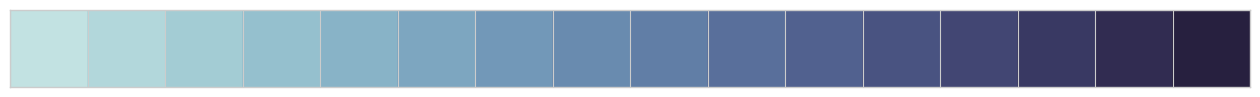

In [117]:
palette = sns.color_palette("ch:start=.2,rot=-.3", 16)
sns.palplot(palette)

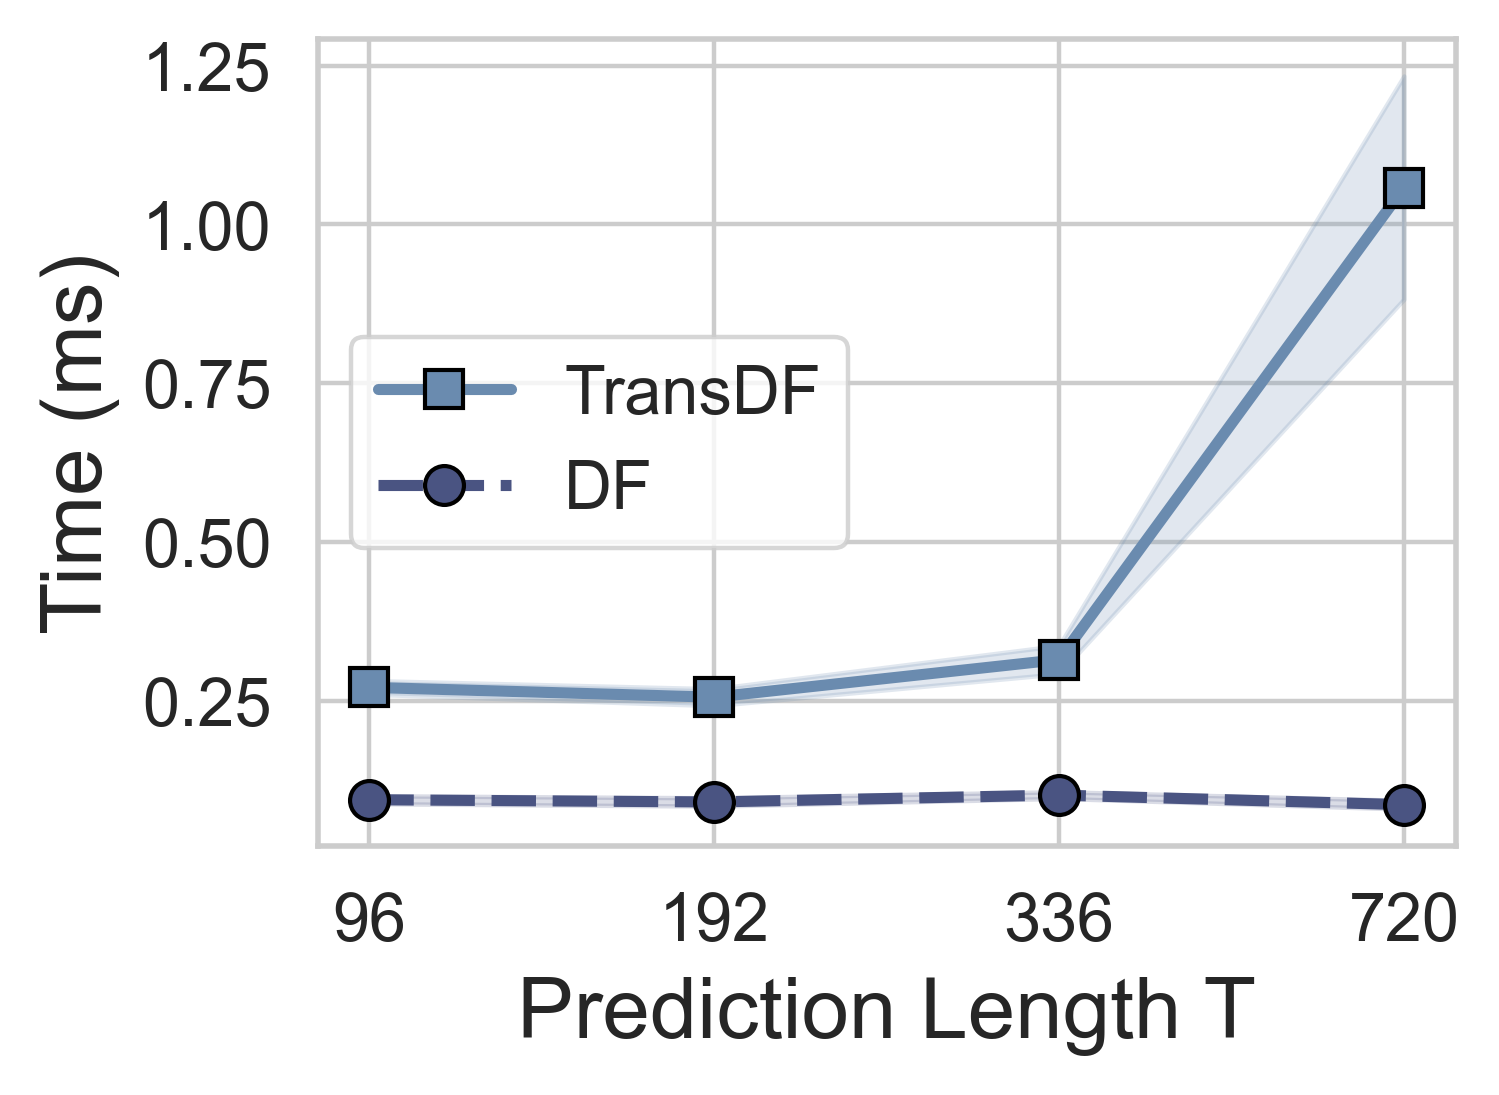

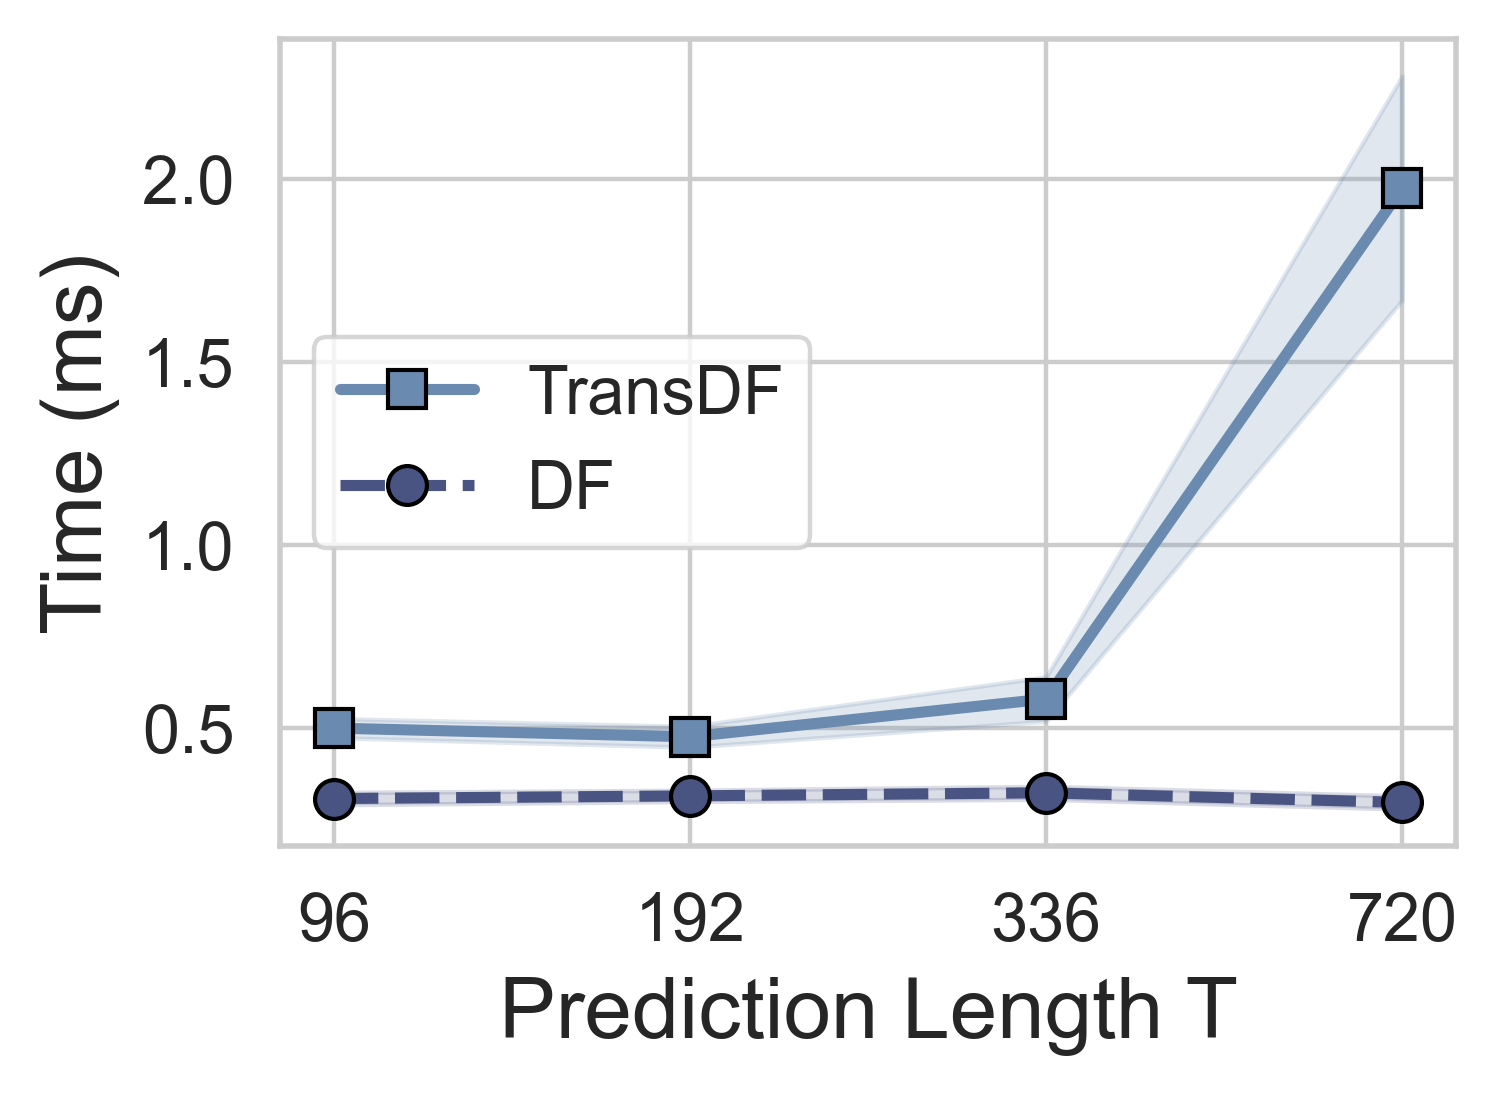

In [136]:
def plot(df, save_dir, figure_name='hparam-study', x='lambda', x_name=r'$\alpha$', y='forward_pass', ytick1=None, ytick2=None, ypad1=0.005, ypad2=0.005, ylim1=None, ylim2=None, xpad=None, xticks=None, base=10, yname=None):
    legend_location = 'center left'  # 这里可以根据图的实际情况调节。
    labelsize = 12
    ci = 95
    z = norm.ppf(1 - (1 - ci / 100) / 2)
    errorbar = lambda x: (x.mean() - z * x.std() / np.sqrt(len(x)), x.mean() + z * x.std() / np.sqrt(len(x)))

    style = ['darkgrid', 'dark', 'white', 'whitegrid', 'ticks']
    context = ['paper', 'notebook', 'talk', 'poster']
    # palette = sns.color_palette('deep')
    # palette = [palette[0], palette[3], palette[2]] + palette[4:]
    # palette = sns.color_palette('Blues_d', 16)
    # palette = [palette[0], palette[12], palette[2]] + palette[4:]
    palette = sns.color_palette("ch:start=.2,rot=-.3", 16)
    palette = [palette[7], palette[11], palette[2]] + palette[4:]
    # palette = sns.color_palette('Purples_d', 16)
    # palette = [palette[0], palette[12], palette[2]] + palette[4:]
    # palette = palette[::-1]
    sns.set_theme(style=style[3], context=context[0], font='Arial', font_scale=1.6, palette=palette)

    f = plt.figure(dpi=400, figsize=(4, 3))  # 如果只画一条线，就用红色，高改为3->2.5
    f.subplots_adjust(top=0.9, left=0.1, right=0.9, bottom=0.2)
    f.add_subplot(1, 1, 1)
    sns.lineplot(x=x, y=y, data=df, hue='alpha', style='alpha', errorbar=errorbar, linewidth=2, markersize=7, markeredgecolor='k', markers=['s', 'o'])
    ax = plt.gca()
    if ypad1:
        ax.yaxis.set_major_locator(plt.MultipleLocator(ypad1))  # 小数点后3位数间隔。
    if xpad:
        ax.xaxis.set_major_locator(plt.MultipleLocator(xpad))
    plt.legend(ncol=1, loc=legend_location, fontsize=labelsize)
    plt.xlabel(x_name)
    # plt.xticks(rotation=90)
    if yname is not None:
        plt.ylabel(yname)
    else:
        plt.ylabel('Time (ms)')
    if base != 10:
        plt.yscale('log', base=base)
    plt.tick_params(labelsize=labelsize)
    if ytick1:
        plt.yticks(ytick1)
    if xticks is not None:
        plt.xticks(xticks)
    if ylim1:
        plt.ylim(ylim1)
    plt.tight_layout()

    with PdfPages(os.path.join(save_dir, f"{figure_name}.pdf")) as pdf:
        pdf.savefig(f, bbox_inches='tight', pad_inches=0.01)


# dfp = df.copy()
# dfp = dfp[['pred_len', 'auxi_lambda', 'forward_pass', 'backward_pass', 'test_forward_pass', 'loss_forward_pass', 'try']]
# dfp.rename(columns={'auxi_lambda': 'alpha'}, inplace=True)
# dfp = dfp[dfp.alpha.isin([0.0, 1.0])]
# dfp['alpha'] = dfp['alpha'].replace({0.0: r'$\alpha=0$', 1.0: r'$\alpha=1$'})
# dfp['pred_len'] = dfp['pred_len'].astype(str)
# dfp['backward_pass'] = dfp['backward_pass'].astype(float) * 1e3

# save_dir = '/data/home/Licheng/workspace/TSF-PCA/figure_PCA/timing'
# os.makedirs(save_dir, exist_ok=True)

# plot(dfp, save_dir=save_dir, figure_name='weather_forward', x='pred_len', x_name=r'Prediction Length T', y='forward_pass', ypad1=None, yname='Time (ms)')

# plot(dfp, save_dir=save_dir, figure_name='weather_loss_forward', x='pred_len', x_name=r'Prediction Length T', y='loss_forward_pass', ypad1=None, yname='Time (ms)')

# plot(dfp, save_dir=save_dir, figure_name='weather_backward', x='pred_len', x_name=r'Prediction Length T', y='backward_pass', ypad1=None, yname='Time (us)')

# plot(dfp, save_dir=save_dir, figure_name='weather_test_forward', x='pred_len', x_name=r'Prediction Length T', y='test_forward_pass', ypad1=None, yname='Time (ms)')

n = 20
def remove_top_bottom(group):
    top = group.sort_values(by='time', ascending=False).iloc[:n].index
    bottom = group.sort_values(by='time', ).iloc[:n].index
    group = group.drop(top)
    group = group.drop(bottom)
    return group

save_root = '/data/home/Licheng/workspace/TSF-PCA/stats_PCA'
dfp = pd.read_csv(os.path.join(save_root, f'weather_pca_loss_time.csv'))
alpha_order = [1.0, 0.0]
dfp['alpha'] = pd.Categorical(dfp['alpha'], categories=alpha_order, ordered=True)

dfp.sort_values(by=['pred_len', 'alpha', 'type'], inplace=True)
dfp['time'] = dfp['time'].astype(float) * 1e3
dfp.groupby(['pred_len', 'type', 'alpha']).apply(remove_top_bottom).reset_index(drop=True)
dfp['pred_len'] = dfp['pred_len'].astype(str)
dfp['alpha'] = dfp['alpha'].replace({0.0: 'DF', 1.0: 'TransDF'})

save_dir = '/data/home/Licheng/workspace/TSF-PCA/figure_PCA/timing'
os.makedirs(save_dir, exist_ok=True)

dfp_ = dfp[dfp.type == 'loss_forward_pass'].copy()
plot(dfp_, save_dir=save_dir, figure_name='weather_forward', x='pred_len', x_name=r'Prediction Length T', y='time', ypad1=None, yname='Time (ms)')

dfp_ = dfp[dfp.type == 'backward_pass'].copy()
plot(dfp_, save_dir=save_dir, figure_name='weather_backward', x='pred_len', x_name=r'Prediction Length T', y='time', ypad1=None, yname='Time (ms)')